Data Wrangling II
Create an “Academic performance” dataset of students and perform the following operations using Python:

1. Scan all variables for missing values and inconsistencies. Use any suitable techniques to handle missing data and/or inconsistencies.

2. Scan all numeric variables for outliers. If there are outliers, apply appropriate techniques to deal with them.

3. Apply data transformations on at least one variable. The transformation should be one of the following reasons:

To improve understanding of the variable

To convert a non-linear relationship into a linear one

To decrease the skewness and convert the distribution into a normal one

Reason and document your approach properly.

In [1]:
import pandas as pd

In [15]:
import numpy as np

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

In [3]:
print(df)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [4]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [5]:
#Remove null values
df.dropna()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [7]:
# Replacing null values

math_mean = df["math score"].mean()
df["math score"] = df["math score"].fillna(math_mean)

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


<Axes: >

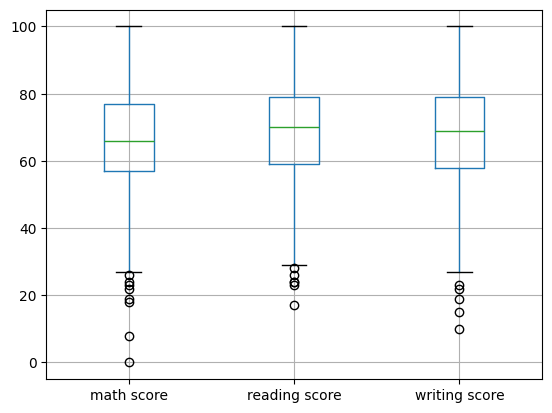

In [9]:
# Outliers

df.boxplot()

In [13]:
#Removing outliers for math score
newdf = df[df["math score"]>30]
newdf


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


<Axes: >

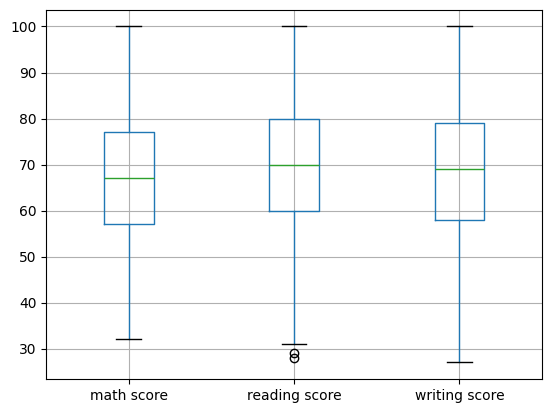

In [14]:
newdf.boxplot()

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

In [23]:
df['log_avg_score'] = np.log(df['average score'])

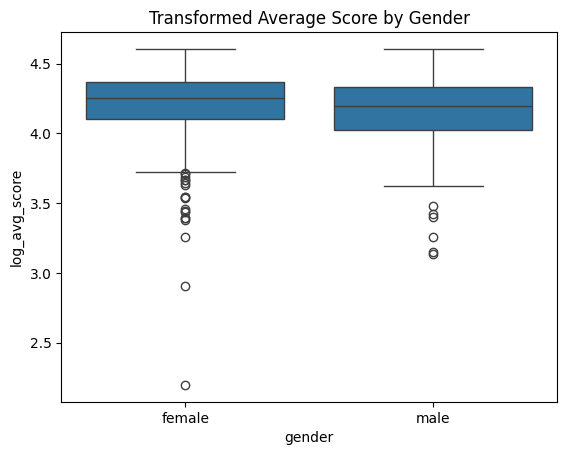

In [26]:
sns.boxplot(x='gender', y='log_avg_score', data=df)
plt.title('Transformed Average Score by Gender')
plt.show()